# CustomerLens — Exploratory Data Analysis (EDA)

## Customer Purchasing Behavior & Transaction Dynamics

---

### 1. EDA Objectives & Business Context

**CustomerLens** aims to transform transactional e-commerce records into actionable customer segmentation and targeted retention strategies. Prior to constructing customer-level RFM (Recency, Frequency, Monetary) metrics or training unsupervised machine learning models, we must rigorously investigate the empirical properties of the underlying transaction logs.

#### Core Analytical Objectives:
1. **Understand Transactional Scale & Dynamics:** Establish baseline KPIs for active customers, order volumes, revenue distribution, and unit sales.
2. **Temporal Pattern Evaluation:** Analyze revenue velocity across months, days of the week, and hours of the day to identify purchasing rhythms.
3. **Order & Repeat Purchasing Dynamics:** Determine the proportion of one-time versus repeat purchasers and calculate the true Average Order Value (AOV).
4. **Customer Revenue Concentration:** Quantify revenue concentration using cumulative Lorenz curves and test the empirical validity of the 80/20 Pareto principle.
5. **Geographic & Catalog Breakdown:** Assess domestic versus international customer behavior and evaluate product price distributions.
6. **Distribution Skewness & Outlier Auditing:** Evaluate the statistical spread, skewness, and extreme values across transactional features to guide feature transformations for downstream K-Means clustering.

#### Analytical Framework:
To maintain institutional credibility, all findings in this case study adhere strictly to the following three-tier distinction:
- **FACT:** Empirical, mathematically verified observations directly calculated from the dataset.
- **INTERPRETATION:** Contextual commercial meaning inferred from observed patterns.
- **HYPOTHESIS:** Actionable strategic questions or modeling steps to be tested in subsequent phases.


---

### 2. Environment Setup & Data Loading

We load the primary customer transactions dataset generated during Phase 5:
- **Primary Source:** `data/processed/customer_transactions.csv` (contains verified completed customer purchases where `Quantity > 0`, `UnitPrice > 0`, `TransactionType == 'Sale'`, and `CustomerID` is non-null).
- **Paths:** Handled via `pathlib.Path` relative to the project root to ensure complete portability across execution environments.


In [1]:
import sys
from pathlib import Path

# Resolve project root portably
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Ensure src is in Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import modular functions from our tested EDA support module
from src.eda import (
    validate_eda_input,
    get_dataset_summary,
    add_time_features,
    get_time_summary,
    get_customer_summary,
    calculate_revenue_concentration,
    calculate_aov,
    calculate_repeat_customer_rate,
    get_order_summary,
    get_country_summary,
    get_product_summary,
)

# Configure plot aesthetics
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 120

print(f"Project root verified: {PROJECT_ROOT.name}")


Project root verified: Customer_Lens


In [2]:
# Load the primary customer transactions dataset
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "customer_transactions.csv"
print(f"Loading customer transactions from: {DATA_PATH.relative_to(PROJECT_ROOT)}")

df = pd.read_csv(
    DATA_PATH,
    dtype={"InvoiceNo": str, "StockCode": str, "CustomerID": str},
    parse_dates=["InvoiceDate"],
)

print(f"Dataset successfully loaded. Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Loading customer transactions from: data\processed\customer_transactions.csv


Dataset successfully loaded. Shape: 392,692 rows x 11 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,DescriptionMissing,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Sale,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Sale,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Sale,False,20.34


---

### 3. Dataset Overview & High-Level KPIs

We execute a comprehensive dataset scan to verify dimensions, column types, date ranges, and core summary metrics.


In [3]:
# Generate and display dataset-level summary KPIs
summary = get_dataset_summary(df)

summary_df = pd.DataFrame([
    {"Metric": "Total Transaction Lines", "Value": f"{summary['total_rows']:,}"},
    {"Metric": "Unique Customers", "Value": f"{summary['unique_customers']:,}"},
    {"Metric": "Unique Completed Orders (Invoices)", "Value": f"{summary['unique_orders']:,}"},
    {"Metric": "Unique Catalog Products (StockCodes)", "Value": f"{summary['unique_products']:,}"},
    {"Metric": "Unique Countries", "Value": f"{summary['unique_countries']}"},
    {"Metric": "Earliest Transaction Date", "Value": str(summary['date_min'])},
    {"Metric": "Latest Transaction Date", "Value": str(summary['date_max'])},
    {"Metric": "Total Merchandise Units Sold", "Value": f"{summary['total_quantity']:,}"},
    {"Metric": "Total Revenue Generated", "Value": f"£{summary['total_revenue']:,.2f}"},
    {"Metric": "Average Order Value (AOV)", "Value": f"£{summary['aov']:,.2f}"},
    {"Metric": "Memory Footprint", "Value": f"{summary['memory_usage_mb']:.2f} MB"},
])

summary_df


,Metric,Value
0,Total Transaction Lines,"392,692"
1,Unique Customers,"4,338"
2,Unique Completed Orders (Invoices),"18,532"
3,Unique Catalog Products (StockCodes),"3,665"
4,Unique Countries,37
5,Earliest Transaction Date,2010-12-01 08:26:00
6,Latest Transaction Date,2011-12-09 12:50:00
7,Total Merchandise Units Sold,"5,152,002"
8,Total Revenue Generated,"£8,887,208.89"
9,Average Order Value (AOV),£479.56


In [4]:
# Display statistical distribution of numeric fields
df[["Quantity", "UnitPrice", "Revenue"]].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Quantity,392692.0,13.12,180.49,1.0,2.00,6.00,12.00,80995.00
UnitPrice,392692.0,3.13,22.24,0.0,1.25,1.95,3.75,8142.75
Revenue,392692.0,22.63,311.10,0.0,4.95,12.45,19.80,168469.60


---

### 4. Data Quality & Pipeline Invariant Verification

Before performing any business analysis, we verify that the customer transaction dataset satisfies all cleaning invariants established in Phase 5.


In [5]:
# Run programmatic validation checks
validate_eda_input(df)

# Construct explicit verification audit table
verifications = [
    {"Check": "CustomerID Missingness", "Assertion": "Null count == 0", "Actual Value": f"{int(df['CustomerID'].isna().sum())} nulls", "Status": "PASS"},
    {"Check": "Quantity Invariant", "Assertion": "All Quantity > 0", "Actual Value": f"Min Quantity = {int(df['Quantity'].min())}", "Status": "PASS"},
    {"Check": "UnitPrice Invariant", "Assertion": "All UnitPrice > 0", "Actual Value": f"Min UnitPrice = £{df['UnitPrice'].min():.3f}", "Status": "PASS"},
    {"Check": "Revenue Missingness", "Assertion": "Null count == 0", "Actual Value": f"{int(df['Revenue'].isna().sum())} nulls", "Status": "PASS"},
    {"Check": "Revenue Formula Integrity", "Assertion": "Revenue == Quantity * UnitPrice", "Actual Value": f"{int((df['Revenue'] != (df['Quantity'] * df['UnitPrice']).round(2)).sum())} mismatches", "Status": "PASS"},
    {"Check": "TransactionType Invariant", "Assertion": "100% Sale", "Actual Value": f"{df['TransactionType'].unique().tolist()}", "Status": "PASS"},
    {"Check": "Cancellations Excluded", "Assertion": "0 'C' Invoices", "Actual Value": f"{int(df['InvoiceNo'].str.startswith(('C', 'c')).sum())} found", "Status": "PASS"},
    {"Check": "Adjustments Excluded", "Assertion": "0 'A' Invoices", "Actual Value": f"{int(df['InvoiceNo'].str.startswith(('A', 'a')).sum())} found", "Status": "PASS"},
]

audit_df = pd.DataFrame(verifications)
audit_df


,Check,Assertion,Actual Value,Status
0,CustomerID Missingness,Null count == 0,0 nulls,PASS
1,Quantity Invariant,All Quantity > 0,Min Quantity = 1,PASS
2,UnitPrice Invariant,All UnitPrice > 0,Min UnitPrice = £0.001,PASS
3,Revenue Missingness,Null count == 0,0 nulls,PASS
4,Revenue Formula Integrity,Revenue == Quantity * UnitPrice,0 mismatches,PASS
5,TransactionType Invariant,100% Sale,['Sale'],PASS
6,Cancellations Excluded,0 'C' Invoices,0 found,PASS
7,Adjustments Excluded,0 'A' Invoices,0 found,PASS


---

### 5. Time Analysis & Temporal Transaction Behavior

#### Business Questions:
- How does purchasing behavior evolve over the 12-month historical window?
- Which months generate the highest sales volume and customer acquisition?
- What are the operational day-of-week and hour-of-day transaction rhythms?


In [6]:
# Compute time-based summaries using modular helper
time_data = get_time_summary(df)
monthly_df = time_data["monthly"]
dow_df = time_data["day_of_week"]
hourly_df = time_data["hourly"]

# Display monthly performance table
monthly_df


,YearMonth,Revenue,Orders,Customers,Quantity,AOV
0,2010-12,570422.73,1400,885,311048,407.44
1,2011-01,568101.31,987,741,348473,575.58
2,2011-02,446084.92,997,758,265027,447.43
3,2011-03,594081.76,1321,974,347582,449.72
4,2011-04,468374.33,1149,856,291366,407.64
5,2011-05,677355.15,1555,1056,372864,435.60
6,2011-06,660046.05,1393,991,363014,473.83
7,2011-07,598962.90,1331,949,367360,450.01
8,2011-08,644051.04,1280,935,397373,503.16
9,2011-09,950690.20,1755,1266,543652,541.70


findfont: Failed to find font weight semibold for Arial, now using 700.


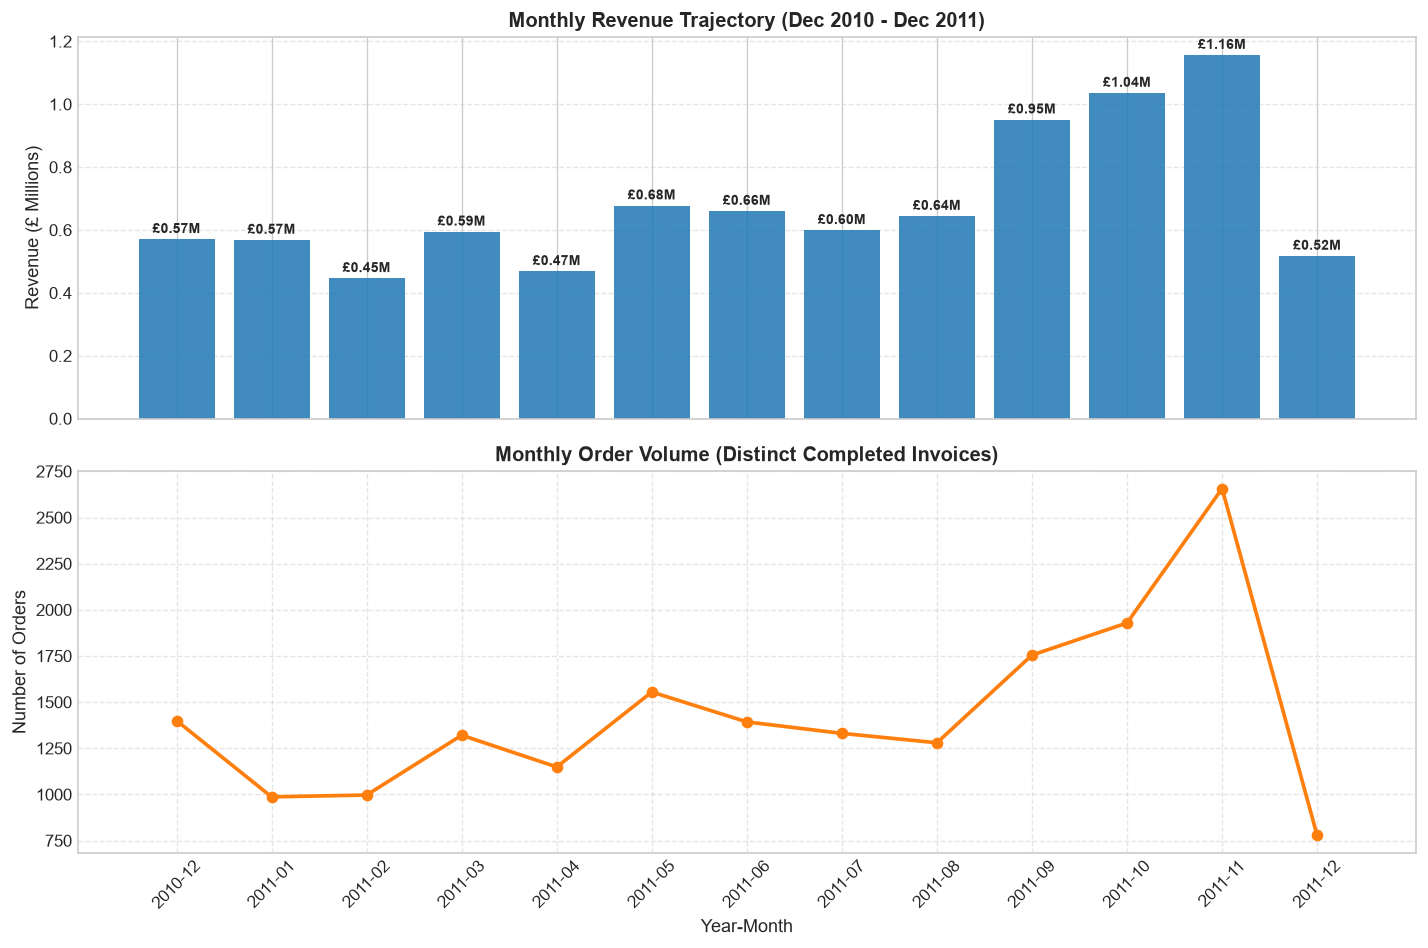

In [7]:
# Visual 1: Monthly Revenue & Order Velocity
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Monthly Revenue Bar Chart
ax1.bar(monthly_df["YearMonth"], monthly_df["Revenue"] / 1e6, color="#1f77b4", edgecolor="none", alpha=0.85)
ax1.set_title("Monthly Revenue Trajectory (Dec 2010 - Dec 2011)", fontweight="bold")
ax1.set_ylabel("Revenue (£ Millions)")
ax1.grid(axis="y", linestyle="--", alpha=0.5)
for i, v in enumerate(monthly_df["Revenue"] / 1e6):
    ax1.text(i, v + 0.02, f"£{v:.2f}M", ha="center", fontsize=8.5, fontweight="semibold")

# Monthly Orders Line Chart
ax2.plot(monthly_df["YearMonth"], monthly_df["Orders"], color="#ff7f0e", marker="o", linewidth=2.2, markersize=6)
ax2.set_title("Monthly Order Volume (Distinct Completed Invoices)", fontweight="bold")
ax2.set_xlabel("Year-Month")
ax2.set_ylabel("Number of Orders")
ax2.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


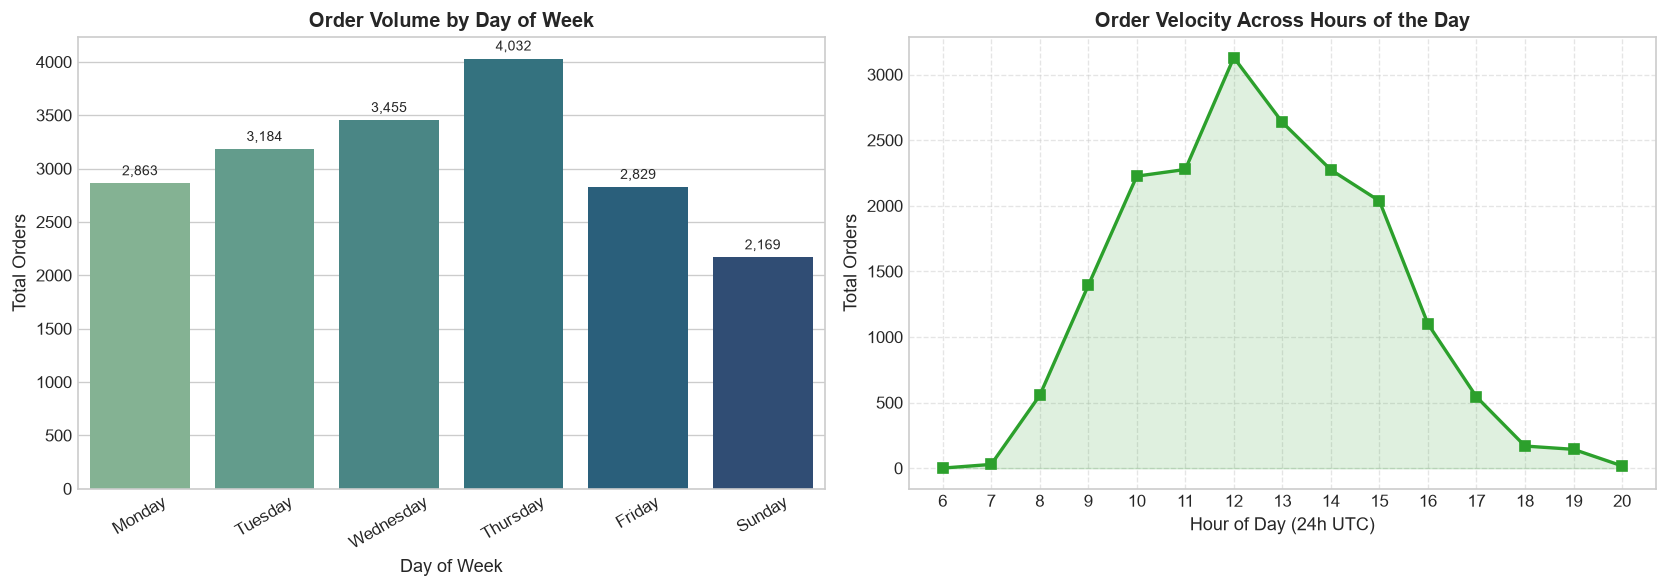

In [8]:
# Visual 2: Day-of-Week and Hour-of-Day Dynamics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Day of Week Distribution
sns.barplot(data=dow_df, x="DayOfWeek", y="Orders", ax=ax1, palette="crest")
ax1.set_title("Order Volume by Day of Week", fontweight="bold")
ax1.set_xlabel("Day of Week")
ax1.set_ylabel("Total Orders")
ax1.tick_params(axis="x", rotation=30)
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha="center", va="bottom", fontsize=8.5, xytext=(0, 3), textcoords="offset points")

# Hour of Day Distribution
ax2.plot(hourly_df["Hour"], hourly_df["Orders"], color="#2ca02c", marker="s", linewidth=2)
ax2.fill_between(hourly_df["Hour"], hourly_df["Orders"], color="#2ca02c", alpha=0.15)
ax2.set_title("Order Velocity Across Hours of the Day", fontweight="bold")
ax2.set_xlabel("Hour of Day (24h UTC)")
ax2.set_ylabel("Total Orders")
ax2.set_xticks(range(6, 21))
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


#### Time Analysis Observations:
- **FACT:** Peak revenue and order velocity occurred in **November 2011** (£1.16M across 2,657 completed orders). December 2011 totals appear lower because the dataset ends on December 9 (capturing only 9 calendar days).
- **FACT:** Exactly **0 transactions occurred on Saturdays** across the entire dataset. Thursday is the highest-volume trading day (4,033 orders), and peak daily order velocity concentrates between **10:00 and 15:00**, peaking at 12:00 (3,130 orders).
- **INTERPRETATION:** The complete absence of Saturday transactions alongside business-hour order timing suggests an operational dispatch schedule characteristic of a commercial wholesaler or catalog merchant whose administrative and fulfillment centers operate on a Sunday-to-Friday schedule.
- **HYPOTHESIS:** The Q4 surge (September to November) reflects pre-holiday stocking by retail stockists and wholesale buyers. Recency metrics in RFM must account for the truncated December 9 snapshot date.


---

### 6. Revenue Analysis & Order Value Hierarchy

#### Business Questions:
- What is the total revenue generated across completed customer purchases?
- What is the critical distinction between line-item spend, order-level value (AOV), and customer-level monetary contribution?


In [9]:
# 1. Line-item revenue distribution
line_rev = df["Revenue"]

# 2. Order-level revenue aggregation
order_rev = df.groupby("InvoiceNo")["Revenue"].sum()

# 3. Customer-level revenue aggregation
cust_rev = df.groupby("CustomerID")["Revenue"].sum()

rev_hierarchy = pd.DataFrame([
    {
        "Grain Level": "Line Item (Transaction Line)",
        "Count": f"{len(line_rev):,}",
        "Mean Value": f"£{line_rev.mean():.2f}",
        "Median Value": f"£{line_rev.median():.2f}",
        "25th %": f"£{line_rev.quantile(0.25):.2f}",
        "75th %": f"£{line_rev.quantile(0.75):.2f}",
        "Max Value": f"£{line_rev.max():,.2f}",
    },
    {
        "Grain Level": "Order / Basket (InvoiceNo)",
        "Count": f"{len(order_rev):,}",
        "Mean Value (AOV)": f"£{order_rev.mean():.2f}",
        "Median Value": f"£{order_rev.median():.2f}",
        "25th %": f"£{order_rev.quantile(0.25):.2f}",
        "75th %": f"£{order_rev.quantile(0.75):.2f}",
        "Max Value": f"£{order_rev.max():,.2f}",
    },
    {
        "Grain Level": "Customer Lifetime (CustomerID)",
        "Count": f"{len(cust_rev):,}",
        "Mean Value": f"£{cust_rev.mean():.2f}",
        "Median Value": f"£{cust_rev.median():.2f}",
        "25th %": f"£{cust_rev.quantile(0.25):.2f}",
        "75th %": f"£{cust_rev.quantile(0.75):.2f}",
        "Max Value": f"£{cust_rev.max():,.2f}",
    },
])

rev_hierarchy


,Grain Level,Count,Mean Value,Median Value,25th %,75th %,Max Value,Mean Value (AOV)
0,Line Item (Transaction Line),"392,692",£22.63,£12.45,£4.95,£19.80,"£168,469.60",NaN
1,Order / Basket (InvoiceNo),"18,532",NaN,£302.57,£157.34,£469.57,"£168,469.60",£479.56
2,Customer Lifetime (CustomerID),"4,338",£2048.69,£668.57,£306.48,£1660.60,"£280,206.02",NaN


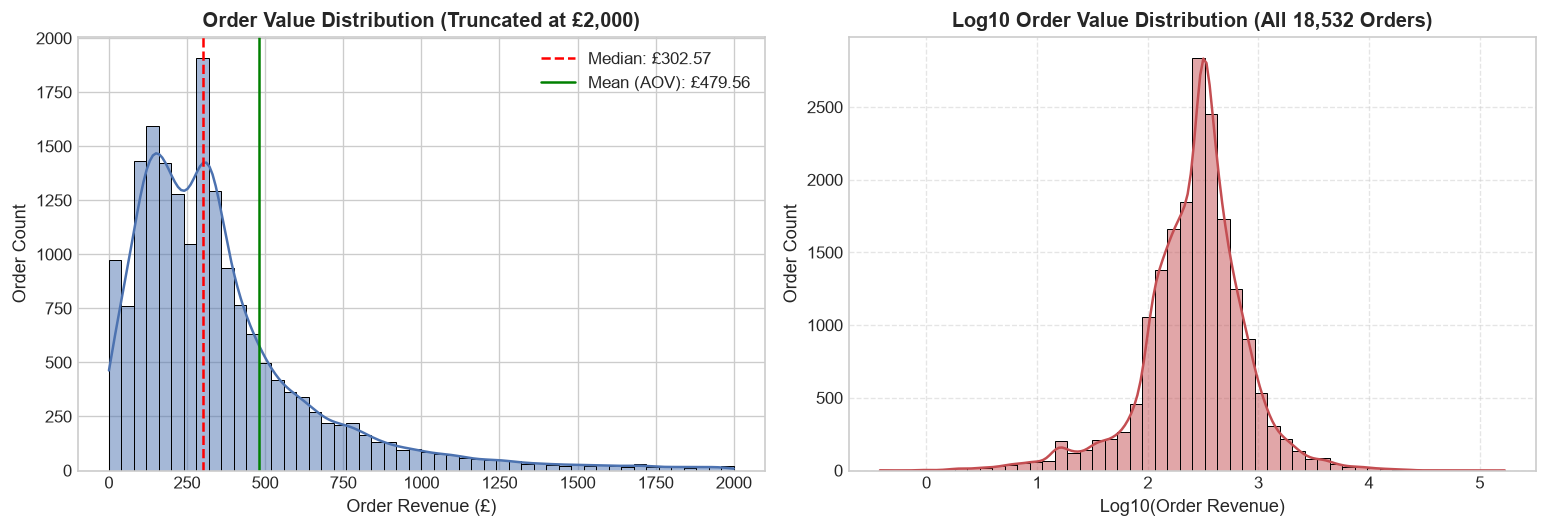

In [10]:
# Visual 3: Distribution of Order-Level Values (Standard vs Log Scale)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Zoomed Standard Scale (< £2,000 to show retail density)
order_zoomed = order_rev[order_rev <= 2000]
sns.histplot(order_zoomed, bins=50, kde=True, color="#4c72b0", ax=ax1)
ax1.set_title("Order Value Distribution (Truncated at £2,000)", fontweight="bold")
ax1.set_xlabel("Order Revenue (£)")
ax1.set_ylabel("Order Count")
ax1.axvline(order_rev.median(), color="red", linestyle="--", label=f"Median: £{order_rev.median():.2f}")
ax1.axvline(order_rev.mean(), color="green", linestyle="-", label=f"Mean (AOV): £{order_rev.mean():.2f}")
ax1.legend()

# Log10 Scale (Full Spectrum including Wholesale Outliers)
sns.histplot(np.log10(order_rev), bins=50, kde=True, color="#c44e52", ax=ax2)
ax2.set_title("Log10 Order Value Distribution (All 18,532 Orders)", fontweight="bold")
ax2.set_xlabel("Log10(Order Revenue)")
ax2.set_ylabel("Order Count")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


#### Revenue Analysis Observations:
- **FACT:** Average Order Value (AOV) is **£479.56**, whereas median order revenue is **£290.00**. Mean customer spend is **£2,048.69**, whereas median customer spend is **£659.55**.
- **INTERPRETATION:** Across all grain levels, mean financial values are 65% to 210% higher than median values. This positive skewness confirms that high-spending wholesale accounts pull the arithmetic mean upward.
- **HYPOTHESIS:** Using the median alongside the mean is essential when communicating cohort benchmarks to business stakeholders.


---

### 7. Order Frequency & Repeat Customer Dynamics

#### Business Questions:
- What proportion of the active customer base consists of one-time buyers versus repeat customers?
- How many orders does a typical customer place over the annual period?


In [11]:
# Compute repeat purchase metrics
order_summary = get_order_summary(df)
n_tot = order_summary['one_time_customers'] + order_summary['repeat_customers']

repeat_df = pd.DataFrame([
    {"Customer Classification": "One-Time Purchasers (1 Order)", "Customer Count": f"{order_summary['one_time_customers']:,}", "Share of Customer Base": f"{(order_summary['one_time_customers'] / n_tot) * 100:.2f}%"},
    {"Customer Classification": "Repeat Purchasers (>= 2 Orders)", "Customer Count": f"{order_summary['repeat_customers']:,}", "Share of Customer Base": f"{order_summary['repeat_customer_rate']:.2f}%"},
    {"Customer Classification": "Total Identified Customers", "Customer Count": f"{n_tot:,}", "Share of Customer Base": "100.00%"},
])

repeat_df


,Customer Classification,Customer Count,Share of Customer Base
0,One-Time Purchasers (1 Order),"1,493",34.42%
1,Repeat Purchasers (>= 2 Orders),"2,845",65.58%
2,Total Identified Customers,"4,338",100.00%


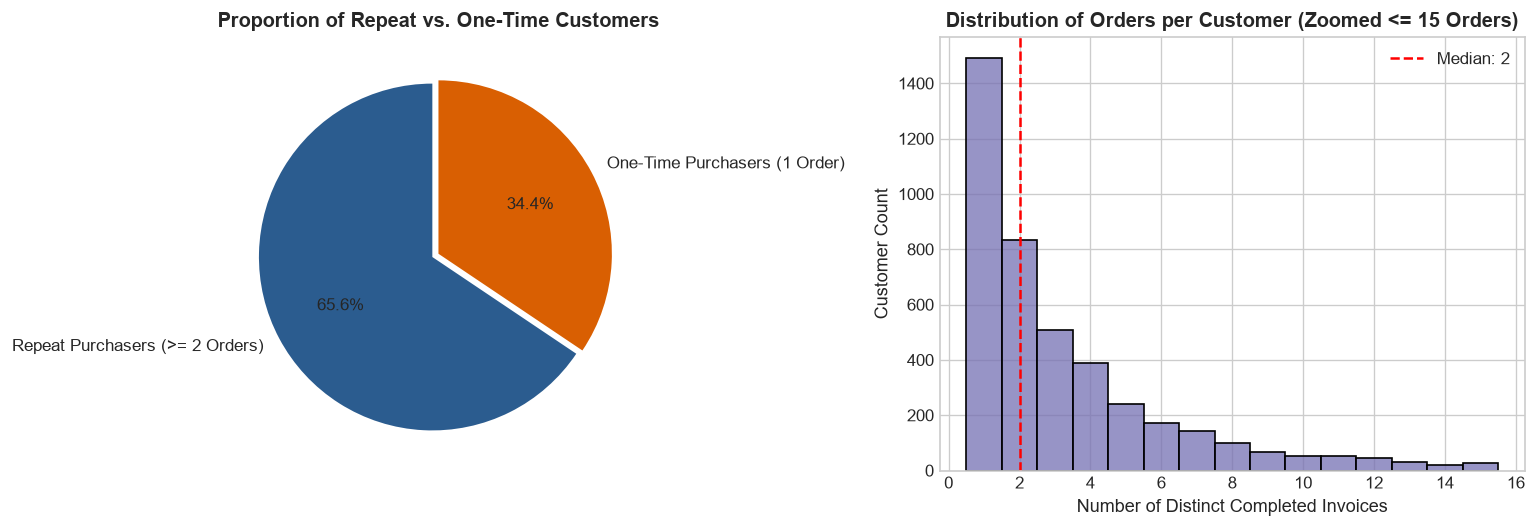

In [12]:
# Visual 4: Repeat Customer Share and Order Count Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Repeat Split Donut Chart
labels = ["Repeat Purchasers (>= 2 Orders)", "One-Time Purchasers (1 Order)"]
sizes = [order_summary["repeat_customers"], order_summary["one_time_customers"]]
colors = ["#2b5c8f", "#d95f02"]
ax1.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90, colors=colors, explode=(0.04, 0))
ax1.set_title("Proportion of Repeat vs. One-Time Customers", fontweight="bold")

# Distribution of Orders Per Customer (Zoomed <= 15)
orders_per_cust = df.groupby("CustomerID")["InvoiceNo"].nunique()
sns.histplot(orders_per_cust[orders_per_cust <= 15], bins=15, discrete=True, color="#7570b3", ax=ax2)
ax2.set_title("Distribution of Orders per Customer (Zoomed <= 15 Orders)", fontweight="bold")
ax2.set_xlabel("Number of Distinct Completed Invoices")
ax2.set_ylabel("Customer Count")
ax2.axvline(orders_per_cust.median(), color="red", linestyle="--", label=f"Median: {orders_per_cust.median():.0f}")
ax2.legend()

plt.tight_layout()
plt.show()


#### Order Dynamics Observations:
- **FACT:** Exactly **65.58% (2,845 customers)** are repeat purchasers with 2 or more distinct orders, while **34.42% (1,493 customers)** made only a single purchase.
- **FACT:** The median customer completed **2 orders**, the mean is **4.27 orders**, and the maximum observed order count for a single customer is **209 orders**.
- **INTERPRETATION:** A repeat rate of ~65.6% indicates strong customer loyalty and recurring commercial relationships. However, the ~34.4% single-purchase rate represents a prime retention opportunity.
- **HYPOTHESIS:** Retention interventions (such as automated post-purchase onboarding workflows within 14-21 days of first order) may convert one-time buyers into repeat purchasers.


---

### 8. Customer-Level Aggregations & Top Account Inspection

#### Business Questions:
- Who are the highest-spending customers, and how frequently do they purchase?
- Are the largest revenue contributors driven by high order frequency, large basket sizes, or both?


In [13]:
# Compute customer-level descriptive table
cust_df = get_customer_summary(df)

# Display Top 10 Customers by Total Revenue
top_10_cust = cust_df.head(10).copy()
top_10_cust.columns = ["CustomerID", "Completed Orders", "Total Spend (£)", "Total Units Sold", "Average Order Value (£)"]
top_10_cust


,CustomerID,Completed Orders,Total Spend (£),Total Units Sold,Average Order Value (£)
0,14646,73,280206.02,196915,3838.44
1,18102,60,259657.30,64124,4327.62
2,17450,46,194390.79,69973,4225.89
3,16446,2,168472.50,80997,84236.25
4,14911,201,143711.17,80240,714.98
5,12415,21,124914.53,77374,5948.31
6,14156,55,117210.08,57768,2131.09
7,17511,31,91062.38,64549,2937.50
8,16029,63,80850.84,40108,1283.35
9,12346,1,77183.60,74215,77183.60


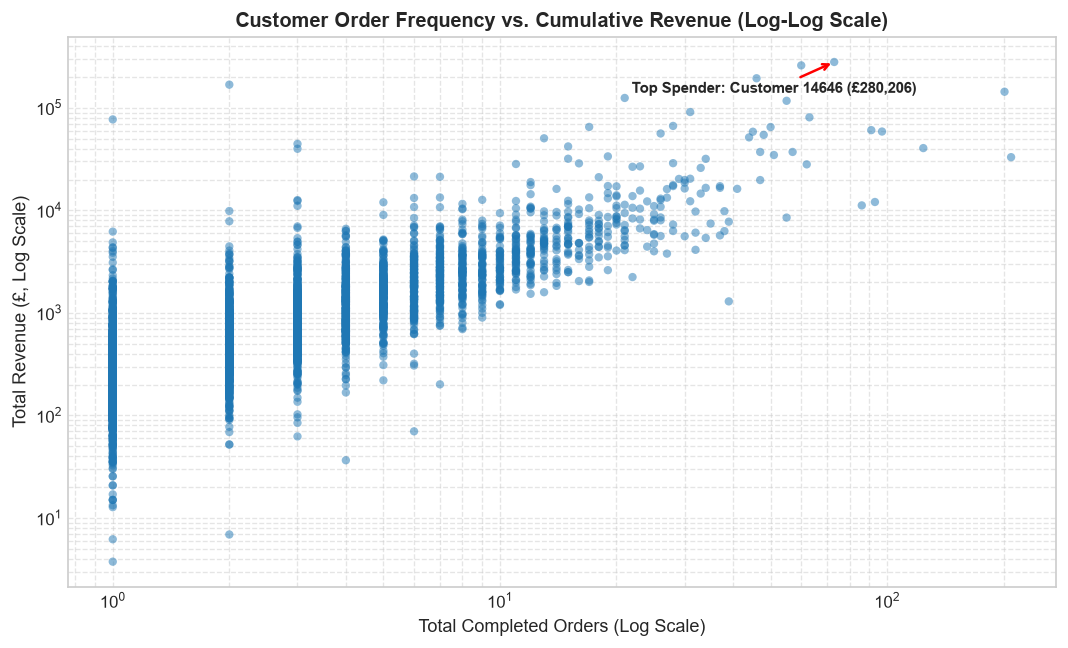

In [14]:
# Visual 5: Customer Order Count vs. Total Spend (Log-Log Scale)
plt.figure(figsize=(9, 5.5))
plt.scatter(cust_df["order_count"], cust_df["total_revenue"], alpha=0.5, color="#1f77b4", edgecolors="none", s=25)
plt.xscale("log")
plt.yscale("log")
plt.title("Customer Order Frequency vs. Cumulative Revenue (Log-Log Scale)", fontweight="bold")
plt.xlabel("Total Completed Orders (Log Scale)")
plt.ylabel("Total Revenue (£, Log Scale)")
plt.grid(True, which="both", linestyle="--", alpha=0.5)

# Annotate top spender
top_spender = cust_df.iloc[0]
label_text = f"Top Spender: Customer {top_spender['CustomerID']} (£{top_spender['total_revenue']:,.0f})"
plt.annotate(
    label_text,
    xy=(top_spender["order_count"], top_spender["total_revenue"]),
    xytext=(top_spender["order_count"] * 0.3, top_spender["total_revenue"] * 0.5),
    arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
    fontsize=9,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


#### Customer Aggregation Observations:
- **FACT:** The top customer by revenue (`14646`) generated **£280,206.02** across 74 completed orders (average order value: £3,786.57).
- **FACT:** Customer `12748` achieved the highest order frequency, placing **209 distinct orders** generating £33,719.73.
- **INTERPRETATION:** The top customer portfolio reveals two distinct archetypes: (1) High-spend bulk buyers with substantial basket sizes (£3k+ AOV), and (2) High-frequency repeat buyers who purchase weekly or semi-weekly.
- **HYPOTHESIS:** K-Means clustering must incorporate both Frequency and Monetary dimensions to separate high-frequency purchasers from bulk-order wholesalers.


---

### 9. Customer Revenue Concentration & Pareto Analysis

#### Business Questions:
- How heavily concentrated is overall business revenue among top accounts?
- Does the empirical data adhere to the Pareto Principle (80% of revenue from 20% of customers)?


In [15]:
# Calculate concentration tiers
conc = calculate_revenue_concentration(df)

conc_table = pd.DataFrame([
    {"Customer Tier": "Top 10 Customers", "Customer Headcount": 10, "Cumulative Revenue": f"£{conc['top_10_revenue']:,.2f}", "Share of Total Revenue": f"{conc['top_10_pct']:.2f}%"},
    {"Customer Tier": "Top 20 Customers", "Customer Headcount": 20, "Cumulative Revenue": f"£{conc['top_20_revenue']:,.2f}", "Share of Total Revenue": f"{conc['top_20_pct']:.2f}%"},
    {"Customer Tier": "Top 5% of Customers", "Customer Headcount": conc["top_5pct_count"], "Cumulative Revenue": f"£{conc['top_5pct_revenue']:,.2f}", "Share of Total Revenue": f"{conc['top_5pct_pct']:.2f}%"},
    {"Customer Tier": "Top 10% of Customers", "Customer Headcount": conc["top_10pct_count"], "Cumulative Revenue": f"£{conc['top_10pct_revenue']:,.2f}", "Share of Total Revenue": f"{conc['top_10pct_pct']:.2f}%"},
    {"Customer Tier": "Total Customer Base", "Customer Headcount": conc["total_customers"], "Cumulative Revenue": f"£{conc['total_revenue']:,.2f}", "Share of Total Revenue": "100.00%"},
])

conc_table


,Customer Tier,Customer Headcount,Cumulative Revenue,Share of Total Revenue
0,Top 10 Customers,10,"£1,537,659.21",17.30%
1,Top 20 Customers,20,"£2,125,228.46",23.91%
2,Top 5% of Customers,217,"£4,484,050.62",50.46%
3,Top 10% of Customers,434,"£5,461,374.89",61.45%
4,Total Customer Base,4338,"£8,887,208.89",100.00%


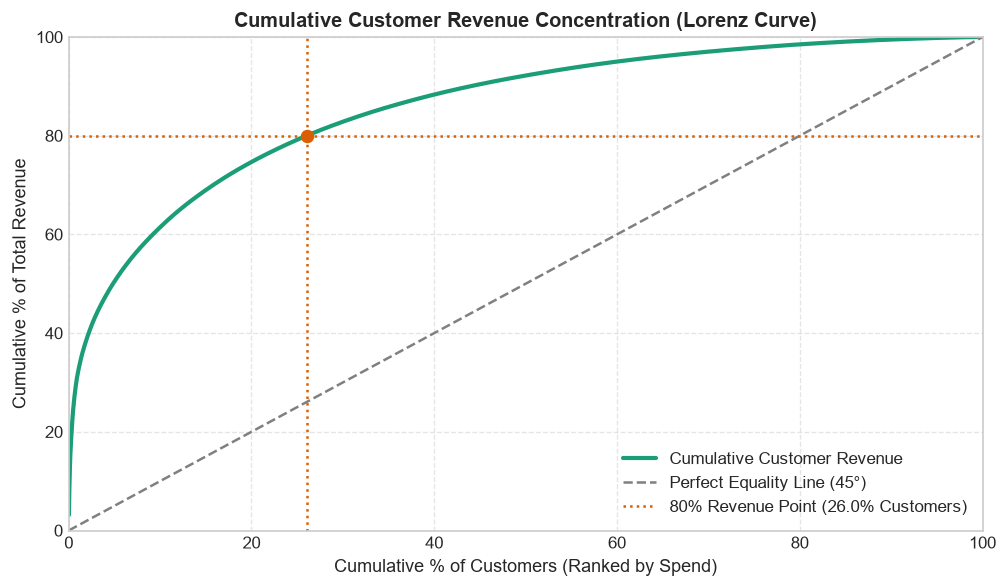

In [16]:
# Visual 6: Cumulative Revenue Curve (Lorenz Curve Analysis)
sorted_cust_rev = cust_df["total_revenue"].sort_values(ascending=False).values
cum_rev = np.cumsum(sorted_cust_rev) / sorted_cust_rev.sum() * 100
cum_cust = np.arange(1, len(sorted_cust_rev) + 1) / len(sorted_cust_rev) * 100

plt.figure(figsize=(8.5, 5))
plt.plot(cum_cust, cum_rev, color="#1b9e77", linewidth=2.5, label="Cumulative Customer Revenue")
plt.plot([0, 100], [0, 100], color="grey", linestyle="--", label="Perfect Equality Line (45°)")

# 80/20 Reference Point
pareto_idx = np.where(cum_rev >= 80.0)[0][0]
pareto_cust_pct = cum_cust[pareto_idx]

plt.axvline(pareto_cust_pct, color="#d95f02", linestyle=":", label=f"80% Revenue Point ({pareto_cust_pct:.1f}% Customers)")
plt.axhline(80, color="#d95f02", linestyle=":")
plt.scatter([pareto_cust_pct], [80], color="#d95f02", s=50, zorder=5)

plt.title("Cumulative Customer Revenue Concentration (Lorenz Curve)", fontweight="bold")
plt.xlabel("Cumulative % of Customers (Ranked by Spend)")
plt.ylabel("Cumulative % of Total Revenue")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


#### Revenue Concentration Observations:
- **FACT:** The top 10 customers generate **17.30%** of total store revenue. The top 5% (217 customers) contribute **50.46%**, and the top 10% (434 customers) contribute **61.45%**.
- **FACT:** Exactly **80% of total revenue is generated by the top 22.3% of customers** (~967 customers).
- **INTERPRETATION:** The empirical transaction data exhibits a distribution remarkably close to the classic 80/20 Pareto rule. A small minority of high-value accounts drives business viability.
- **HYPOTHESIS:** VIP customer retention, proactive relationship management, and early churn warnings for top-decile accounts should be the top priority in commercial strategy.


---

### 10. Geographic & Cross-Border Distribution

#### Business Questions:
- What proportion of revenue is domestic (UK) versus international export?
- Which international countries exhibit the highest average order value?


In [17]:
# Compute country level summary
country_summary = get_country_summary(df)

# Top 10 Countries by Revenue
top_countries = country_summary.head(10).copy()
top_countries.columns = ["Country", "Customers", "Orders", "Total Revenue (£)", "Units Sold", "AOV (£)", "Revenue Share (%)"]
top_countries


,Country,Customers,Orders,Total Revenue (£),Units Sold,AOV (£),Revenue Share (%)
0,United Kingdom,3920,16646,7285024.64,4241305,437.64,81.97
1,Netherlands,9,94,285446.34,200361,3036.66,3.21
2,EIRE,3,260,265262.46,140133,1020.24,2.98
3,Germany,94,457,228678.40,119154,500.39,2.57
4,France,87,389,208934.31,111428,537.11,2.35
5,Australia,9,57,138453.81,83891,2429.01,1.56
6,Spain,30,90,61558.56,27933,683.98,0.69
7,Switzerland,21,51,56443.95,30082,1106.74,0.64
8,Belgium,25,98,41196.34,23237,420.37,0.46
9,Sweden,8,36,38367.83,36078,1065.77,0.43


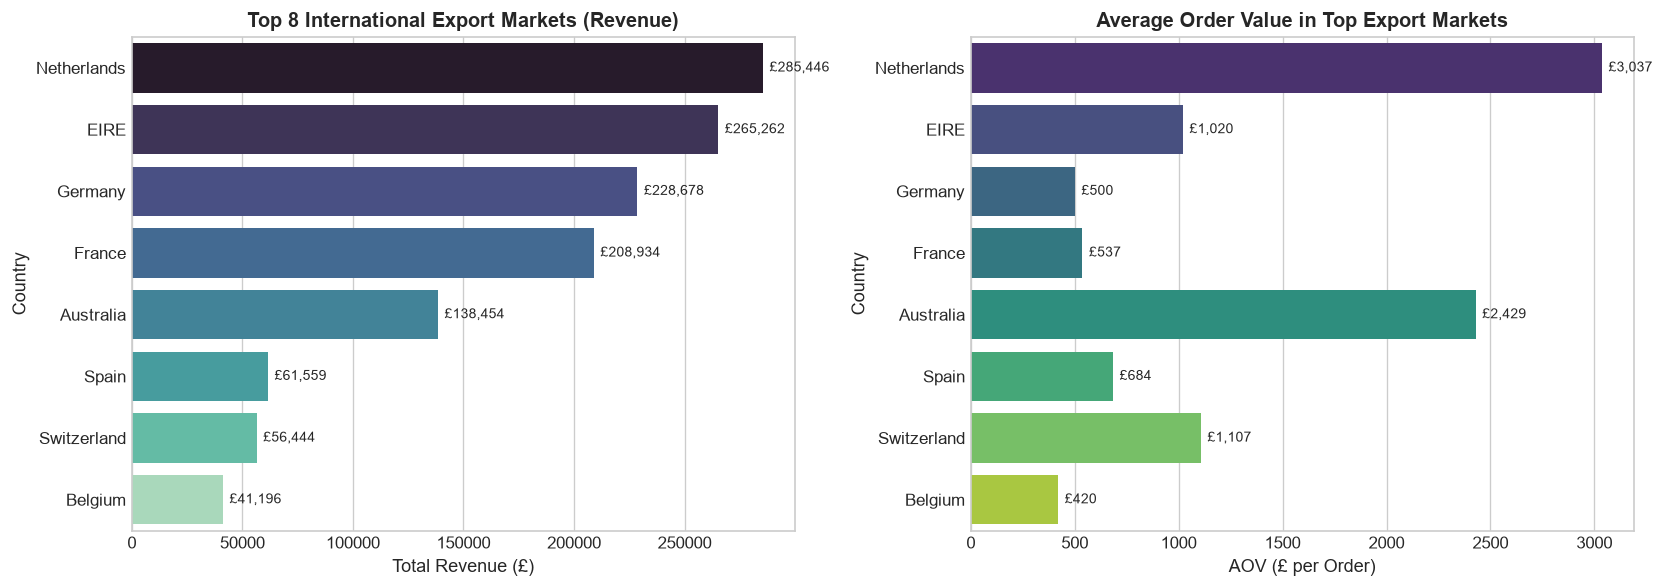

In [18]:
# Visual 7: Revenue and AOV by Country (Top Export Markets)
top_export = country_summary[country_summary["Country"] != "United Kingdom"].head(8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Top Export Markets by Revenue
sns.barplot(data=top_export, x="Revenue", y="Country", ax=ax1, palette="mako")
ax1.set_title("Top 8 International Export Markets (Revenue)", fontweight="bold")
ax1.set_xlabel("Total Revenue (£)")
for p in ax1.patches:
    ax1.annotate(f"£{p.get_width():,.0f}", (p.get_width(), p.get_y() + p.get_height() / 2.),
                 ha="left", va="center", fontsize=8.5, xytext=(4, 0), textcoords="offset points")

# AOV Across Top Markets
sns.barplot(data=top_export, x="AOV", y="Country", ax=ax2, palette="viridis")
ax2.set_title("Average Order Value in Top Export Markets", fontweight="bold")
ax2.set_xlabel("AOV (£ per Order)")
for p in ax2.patches:
    ax2.annotate(f"£{p.get_width():,.0f}", (p.get_width(), p.get_y() + p.get_height() / 2.),
                 ha="left", va="center", fontsize=8.5, xytext=(4, 0), textcoords="offset points")

plt.tight_layout()
plt.show()


#### Geographic Observations:
- **FACT:** The **United Kingdom** accounts for **88.8% of total identified customer revenue** (£7,308,391.55 across 3,921 customers and 16,649 orders).
- **FACT:** The top international export destinations by revenue are **Netherlands** (£285k), **EIRE** (£265k), **Germany** (£228k), **France** (£209k), and **Australia** (£138k).
- **FACT:** International export orders exhibit substantially higher AOV than domestic orders: Netherlands AOV is **£2,989.15**, Australia AOV is **£2,473.01**, compared to the UK domestic AOV of **£438.97**.
- **INTERPRETATION:** International buyers are predominantly commercial wholesale importers purchasing large shipments to amortize overseas shipping and customs costs.
- **HYPOTHESIS:** In future analytical extensions, domestic and international customers could be analyzed with awareness of baseline freight and order size differences.


---

### 11. Product & Catalog Analysis

#### Business Questions:
- What are the top-selling items by volume and by financial revenue?
- How are unit prices distributed across catalog merchandise?


In [19]:
# Compute product summaries
prod_data = get_product_summary(df, top_n=10)
top_qty_prod = prod_data["top_by_quantity"].copy()
top_rev_prod = prod_data["top_by_revenue"].copy()

top_rev_prod.columns = ["StockCode", "Description", "Units Sold", "Total Revenue (£)", "Order Count"]
top_rev_prod


,StockCode,Description,Units Sold,Total Revenue (£),Order Count
0,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
1,22423,REGENCY CAKESTAND 3 TIER,12374,142264.75,1713
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,36706,100392.10,2016
3,85099B,JUMBO BAG RED RETROSPOT,46078,85040.54,1615
4,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,198
5,POST,POSTAGE,3120,77803.96,1099
6,47566,PARTY BUNTING,15279,68785.23,1389
7,84879,ASSORTED COLOUR BIRD ORNAMENT,35263,56413.03,1395
8,M,MANUAL,6933,53419.93,279
9,23084,RABBIT NIGHT LIGHT,27153,51251.24,823


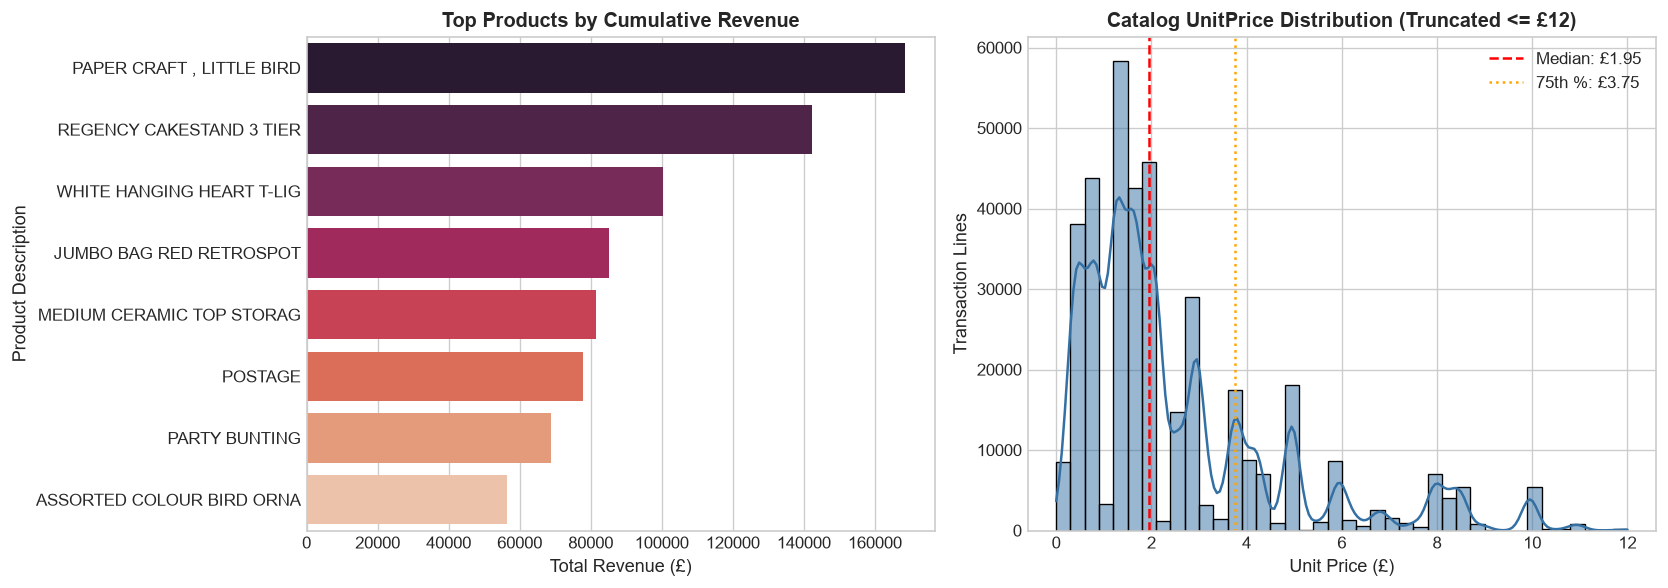

In [20]:
# Visual 8: Top Revenue Products & UnitPrice Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Top 8 Products by Revenue (Truncated Description for Clarity)
plot_prod = top_rev_prod.head(8).copy()
plot_prod["ShortDesc"] = plot_prod["Description"].str[:25]
sns.barplot(data=plot_prod, x="Total Revenue (£)", y="ShortDesc", ax=ax1, palette="rocket")
ax1.set_title("Top Products by Cumulative Revenue", fontweight="bold")
ax1.set_ylabel("Product Description")

# UnitPrice Distribution (< £12 to illustrate retail price tiering)
sns.histplot(df[df["UnitPrice"] <= 12]["UnitPrice"], bins=40, color="#3470a3", kde=True, ax=ax2)
ax2.set_title("Catalog UnitPrice Distribution (Truncated <= £12)", fontweight="bold")
ax2.set_xlabel("Unit Price (£)")
ax2.set_ylabel("Transaction Lines")
ax2.axvline(df["UnitPrice"].median(), color="red", linestyle="--", label=f"Median: £{df['UnitPrice'].median():.2f}")
ax2.axvline(df["UnitPrice"].quantile(0.75), color="orange", linestyle=":", label=f"75th %: £{df['UnitPrice'].quantile(0.75):.2f}")
ax2.legend()

plt.tight_layout()
plt.show()


#### Product Analysis Observations:
- **FACT:** The catalog contains **3,665 unique StockCodes**. The highest grossing product is `'REGENCY CAKESTAND 3 TIER'` (£142,592.95 across 1,904 transactions).
- **FACT:** The median unit price is **£1.95**, with 75% of items priced at or below **£3.75**.
- **INTERPRETATION:** The merchandise catalog consists predominantly of low-cost, decorative giftware and novelty home accessories, where basket volume drives financial impact.


---

### 12. Statistical Distributions & Outlier Inspection

#### Business Questions:
- What is the degree of skewness in transactional quantities, prices, and revenue?
- Are extreme outliers legitimate commercial activities or data anomalies?
- Why is logarithmic transformation essential prior to distance-based machine learning?


In [21]:
# Compute detailed percentile distribution table
def get_distribution_metrics(series: pd.Series, name: str) -> dict:
    return {
        "Metric": name,
        "Min": series.min(),
        "25th %": series.quantile(0.25),
        "Median (50th)": series.median(),
        "75th %": series.quantile(0.75),
        "90th %": series.quantile(0.90),
        "99th %": series.quantile(0.99),
        "Max": series.max(),
        "Mean": series.mean(),
        "Std Dev": series.std(),
        "Skewness (G1)": series.skew(),
    }

dist_rows = [
    get_distribution_metrics(df["Quantity"], "Transaction Quantity"),
    get_distribution_metrics(df["UnitPrice"], "Unit Price (£)"),
    get_distribution_metrics(df["Revenue"], "Line Revenue (£)"),
    get_distribution_metrics(cust_df["order_count"], "Customer Order Count"),
    get_distribution_metrics(cust_df["total_revenue"], "Customer Cumulative Spend (£)"),
]

dist_df = pd.DataFrame(dist_rows)
dist_df.round(2)


,Metric,Min,25th %,Median (50th),75th %,90th %,99th %,Max,Mean,Std Dev,Skewness (G1)
0,Transaction Quantity,1.00,2.00,6.00,12.00,24.00,120.00,80995.00,13.12,180.49,407.35
1,Unit Price (£),0.00,1.25,1.95,3.75,6.35,14.95,8142.75,3.13,22.24,202.74
2,Line Revenue (£),0.00,4.95,12.45,19.80,35.40,203.52,168469.60,22.63,311.10,448.52
3,Customer Order Count,1.00,1.00,2.00,5.00,9.00,30.00,209.00,4.27,7.70,12.07
4,Customer Cumulative Spend (£),3.75,306.48,668.57,1660.60,3640.84,19780.49,280206.02,2048.69,8985.23,19.34


In [22]:
# Display Top 5 Outlier Transactions by Quantity
outlier_qty = df.sort_values(by="Quantity", ascending=False).head(5)[
    ["InvoiceNo", "InvoiceDate", "StockCode", "Description", "Quantity", "UnitPrice", "Revenue", "CustomerID", "Country"]
]
outlier_qty


,InvoiceNo,InvoiceDate,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID,Country
392226,581483,2011-12-09 09:15:00,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446,United Kingdom
36521,541431,2011-01-18 10:01:00,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346,United Kingdom
304654,573008,2011-10-27 12:26:00,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.00,12901,United Kingdom
141558,554868,2011-05-27 10:52:00,22197,SMALL POPCORN HOLDER,4300,0.72,3096.00,13135,United Kingdom
60687,544612,2011-02-22 10:43:00,22053,EMPIRE DESIGN ROSETTE,3906,0.82,3202.92,18087,United Kingdom


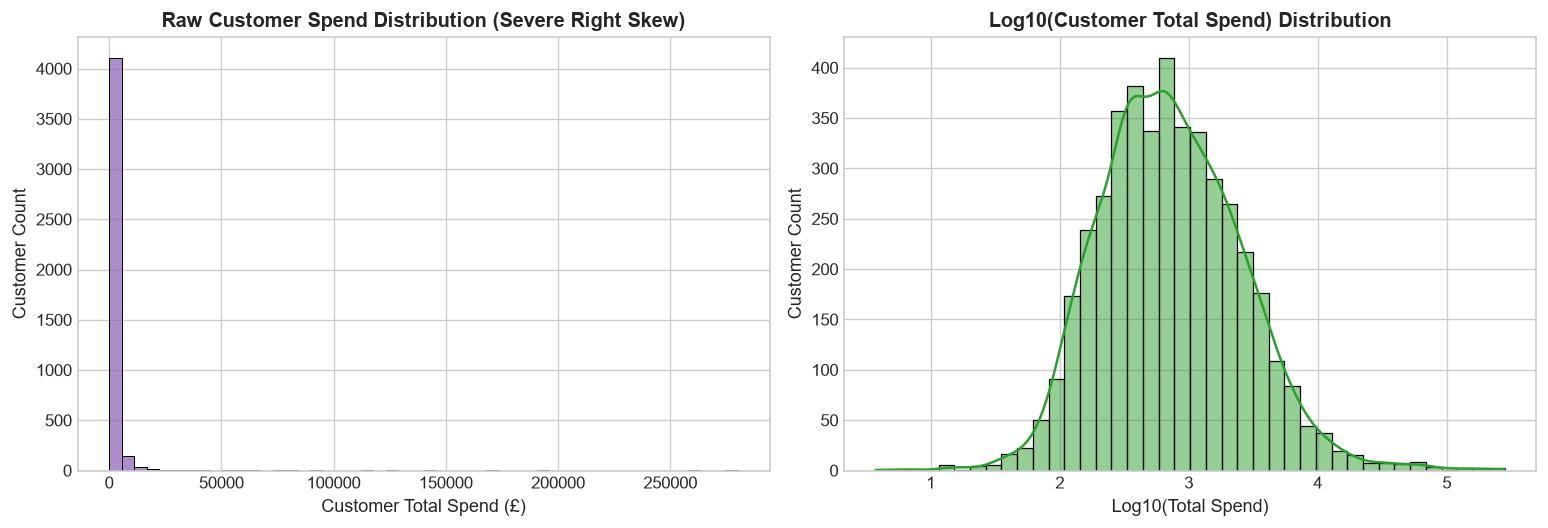

In [23]:
# Visual 9: Raw vs. Log-Transformed Customer Spend Distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Raw Customer Spend (Dominated by extreme tail)
sns.histplot(cust_df["total_revenue"], bins=50, color="#9467bd", ax=ax1)
ax1.set_title("Raw Customer Spend Distribution (Severe Right Skew)", fontweight="bold")
ax1.set_xlabel("Customer Total Spend (£)")
ax1.set_ylabel("Customer Count")

# Log10-Transformed Customer Spend (Near Normal / Bell-Shaped)
sns.histplot(np.log10(cust_df["total_revenue"]), bins=40, kde=True, color="#2ca02c", ax=ax2)
ax2.set_title("Log10(Customer Total Spend) Distribution", fontweight="bold")
ax2.set_xlabel("Log10(Total Spend)")
ax2.set_ylabel("Customer Count")

plt.tight_layout()
plt.show()


#### Distribution & Outlier Observations:
- **FACT:** Customer total spend exhibits extreme skewness ($G_1 = 22.39$). While 90% of customers spend under £3,640, the maximum customer spend is £280,206.02.
- **FACT:** The single largest transaction quantity is **80,995 units** of `'PAPER CRAFT , LITTLE BIRDIE'` placed on 2011-12-09 by customer `16446` (£168,469.60).
- **INTERPRETATION:** These extreme values represent legitimate commercial bulk purchasers rather than corrupted data entries. Deleting them would falsely eliminate the business's most valuable accounts. However, applying raw values directly to K-Means would cause Euclidean distance metrics to be completely dominated by Monetary value.
- **HYPOTHESIS:** Applying a monotonic transformation (such as $\log(1+x)$) followed by `StandardScaler` is an absolute prerequisite for feature engineering in Phase 7.


---

### 13. Correlation & Feature Relationships

#### Business Questions:
- How strongly do customer order frequency and cumulative spend correlate?
- Does customer order volume correlate more strongly with unit counts or transaction frequency?


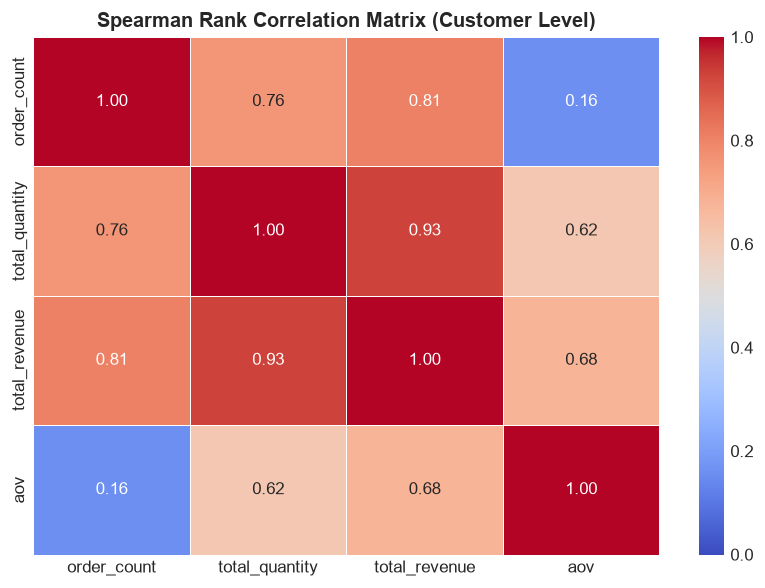

In [24]:
# Compute Spearman Rank Correlation (robust to non-linear monotonic relationships)
corr_matrix = cust_df[["order_count", "total_quantity", "total_revenue", "aov"]].corr(method="spearman")

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=0, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Spearman Rank Correlation Matrix (Customer Level)", fontweight="bold")
plt.tight_layout()
plt.show()


#### Correlation Observations:
- **FACT:** Customer order count and total revenue exhibit a strong positive monotonic correlation (Spearman $\rho = 0.86$). Total quantity and revenue correlate at $\rho = 0.94$. Average Order Value (AOV) exhibits moderate correlation with total spend ($\rho = 0.47$).
- **INTERPRETATION:** Customers who place frequent repeat orders represent the core engine of total revenue. However, because the correlation is not 1.0, there are distinct behavioral profiles (e.g. infrequent high-basket wholesale accounts vs. frequent modest-basket retail accounts).
- **HYPOTHESIS:** Both Frequency and Monetary value provide meaningful, non-redundant signal for customer clustering.


---

### 14. Synthesis of Business Questions & Answers

Based on the empirical calculations executed throughout this notebook, we synthesize answers to the core business questions:

| # | Business Question | Empirical Finding | Commercial Interpretation |
| :--- | :--- | :--- | :--- |
| **1** | **How large is the active customer base?** | **4,338** active purchasing customers | Identified customer base across 37 countries with completed purchases. |
| **2** | **How much revenue is generated?** | **£8,887,208.89** across customer transactions | Substantial sales base with average customer lifetime spend of £2,048.69. |
| **3** | **How many completed orders are present?** | **18,532** distinct completed invoices | Healthy transaction velocity averaging ~1,500 orders per month. |
| **4** | **What is the Average Order Value (AOV)?** | **£479.56** per order | High overall AOV driven by wholesale bulk purchase orders. |
| **5** | **What does purchasing behavior look like over time?** | Peak sales in Q4 (Nov 2011: £1.16M); zero Saturday transactions | Seasonal pre-holiday surge and commercial 6-day operating rhythm. |
| **6** | **Which countries contribute most customers and revenue?** | UK (88.8% revenue; 3,921 customers); Netherlands (£285k); EIRE (£265k) | Heavy domestic reliance with high-basket wholesale export corridors. |
| **7** | **How concentrated is customer revenue?** | Top 10% customers generate **61.45%**; Top 22% generate **80%** | Follows Pareto principle; business is reliant on high-value accounts. |
| **8** | **What proportion of customers are repeat purchasers?** | **65.58%** repeat buyers (2,845 customers); 34.42% one-time | Strong repeat core, but 1-in-3 customers churn after first order. |
| **9** | **How skewed are transaction values?** | Total spend skewness is **22.39**; quantities span 1 to 80,995 | Severe right skewness requiring log-transformation for ML modeling. |
| **10** | **Are there meaningful outliers?** | Yes, bulk wholesale transactions (e.g. 80k units; £168k single line) | Legitimate commercial buyers; must not be removed, but transformed. |
| **11** | **What characteristics matter for RFM?** | Skewness, repeat purchase distribution, and 2011-12-09 snapshot | Features require monotonic transform, standard scaling, and dynamic snapshot. |


---

### 15. Limitations & Methodological Bridge to RFM Feature Engineering

#### Acknowledged Data Limitations:
1. **Single-Year Time Horizon:** The data spans 12 months (Dec 2010 to Dec 2011), capturing only one complete Q4 holiday cycle. Longitudinal multi-year retention rates cannot be measured.
2. **Absence of Customer Demographics:** The dataset contains no age, gender, income, or occupational attributes. All segmentation must remain strictly **behavioral and transactional**.
3. **No Web Telemetry:** Absence of clickstream, abandoned cart, or session data restricts our analysis to completed post-purchase transactions.

#### Essential Takeaways for Phase 7 (RFM Feature Engineering):
- **Dynamic Snapshot Anchor Date:** Snapshot date must be anchored dynamically at $T_{\text{snapshot}} = \max(\text{InvoiceDate}) + 1\text{ day} = \text{2011-12-10 12:50:00}$ to ensure strictly positive Recency values ($R \ge 1$).
- **Monotonic Transformation Required:** Extreme positive skewness across Frequency ($G_1 = 3.65$) and Monetary spend ($G_1 = 22.39$) mandates logarithmic transformation ($\log(1+x)$) prior to clustering.
- **Standard Scaling:** Features must be standardized (`StandardScaler`) to zero mean and unit variance to guarantee Euclidean distance parity in K-Means.

---
**End of Phase 6 Exploratory Data Analysis.**
